# Drive Mount

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive


# Import Tensorflow and Keras

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Data Directory

In [3]:
import os
from keras.preprocessing.image import ImageDataGenerator
#base_dir = '/content/drive/My Drive/Colab Notebooks/Data Sets/cat and dog'
base_dir = '/content/drive/My Drive/Colab Notebooks/dataset_test'
#base_dir = '/content/drive/My Drive/Colab Notebooks/Data Sets/COVID 19 Original'
#base_dir = '/content/drive/My Drive/Colab Notebooks/dataset'
#base_dir = '/content/drive/My Drive/dataset'

train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

Using TensorFlow backend.


# Initialization

In [4]:
#image_size = (224, 224)
image_size = (300, 300) # efficienetB3
batch_size = 16
#batch_size = 6
LEARNING_RATE=0.0001
num_classes=3
#epochs = 5
#epochs = 10
#epochs = 20
epochs = 30

# Training, Validation and Testing data load and Train without Augmentation

In [5]:
trdata=tf.keras.preprocessing.image.ImageDataGenerator( 
    validation_split=0.5
)

train_ds = trdata.flow_from_directory(
    directory=train_dir,
    target_size=image_size,
    class_mode="categorical",
    subset="training",
    batch_size=batch_size,
    shuffle=True,
)

valdata=tf.keras.preprocessing.image.ImageDataGenerator()

val_ds = trdata.flow_from_directory(
    directory=train_dir,
    target_size=image_size,
    class_mode="categorical",
    subset="validation",
    batch_size=batch_size,
)

testdata=tf.keras.preprocessing.image.ImageDataGenerator()

test_ds = testdata.flow_from_directory(
    directory=test_dir,
    target_size=image_size,
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False,
)



Found 18 images belonging to 3 classes.
Found 18 images belonging to 3 classes.
Found 18 images belonging to 3 classes.


# Efficientnet Installation

In [6]:
!pip install -U git+https://github.com/qubvel/efficientnet

  Cloning https://github.com/qubvel/efficientnet to /tmp/pip-req-build-v8cw8xmt
  Running command git clone -q https://github.com/qubvel/efficientnet /tmp/pip-req-build-v8cw8xmt
  Created wheel for efficientnet: filename=efficientnet-1.1.0-cp36-none-any.whl size=18398 sha256=70a5be41784dd987dfb943809b53dee30276c958dbcc5c9f8555458a8f7a4903
  Stored in directory: /tmp/pip-ephem-wheel-cache-gv8ep2ct/wheels/64/60/2e/30ebaa76ed1626e86bfb0cc0579b737fdb7d9ff8cb9522663a
Successfully built efficientnet


# Swish Activation

In [7]:
from keras.backend import sigmoid
from keras.utils import get_custom_objects
from keras.layers import Activation

class SwishActivation(Activation):
    
    def __init__(self, activation, **kwargs):
        super(SwishActivation, self).__init__(activation, **kwargs)
        self.__name__ = 'swish_act'

def swish_act(x, beta = 1):
    return (x * sigmoid(beta * x))


get_custom_objects().update({'swish_act': SwishActivation(swish_act)})

# EfficientNet/DenseNet121/MobileNetV2 Transfer Learning and Fine Tuned

In [8]:
from keras import layers
from keras.layers import AveragePooling2D, BatchNormalization
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Input
from keras.models import Model
from keras.optimizers import Adam
from keras.optimizers import SGD
from keras.applications import DenseNet121
from keras.applications import MobileNetV2

from keras import optimizers
import efficientnet.keras as enet

base_model = enet.EfficientNetB3(include_top=False, input_shape=(300,300,3), pooling='avg', weights="imagenet",classes=num_classes)

x = base_model.output # This is output of CNN.   

x = BatchNormalization()(x)

# Start of Neural Network Part
x = Dense(512)(x)    # Change here. Dense Means hidden layer. Change 128/256/512/1024
x = BatchNormalization()(x)
x = Activation(swish_act)(x)
x = Dropout(0.5)(x)  # Change this drop out either 0.1/0.2/0.3/0.5/0.6/0.7

x = Dense(128)(x)   # Change here. Dense Means hidden layer. Change 128/256/512/1024
x = BatchNormalization()(x)
x = Activation(swish_act)(x)
x = Dropout(0.7)(x)  # Change this drop out either 0.1/0.2/0.3/0.5/0.6/0.7

# Output layer
predictions = Dense(num_classes, activation="softmax")(x)

model= Model(inputs = base_model.input, outputs = predictions)

model.compile(loss='categorical_crossentropy',optimizer=optimizers.Adam(lr=LEARNING_RATE),metrics=['acc'])
model.summary()
model.save('/content/drive/My Drive/Colab Notebooks/model_base.h5')
#plot_model(model)
# End of Neural Network Part

44113920/44107200 [==============================] - 0s 0us/step
Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            (None, 300, 300, 3)  0                                            
__________________________________________________________________________________________________
stem_conv (Conv2D)              (None, 150, 150, 40) 1080        input_1[0][0]                    
__________________________________________________________________________________________________
stem_bn (BatchNormalization)    (None, 150, 150, 40) 160         stem_conv[0][0]                  
__________________________________________________________________________________________________
stem_activation (Activation)    (None, 150, 150, 40) 0           stem_bn[0][0]                    
___________________________

# Model Fit

In [9]:
from keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau
#from swa.tfkeras import SWA
start_epoch = 2

# define swa callback
'''swa = SWA(start_epoch=start_epoch, 
          lr_schedule='cyclic', 
          swa_lr=0.001,
          swa_lr2=0.003,
          swa_freq=3,
          verbose=1)'''

checkpoint = ModelCheckpoint('/content/drive/My Drive/Colab Notebooks/model.h5', monitor='val_acc',save_best_only=True,)
early = EarlyStopping(monitor='val_acc', min_delta=0, patience=20, verbose=1, mode='auto')
reduce_lr = ReduceLROnPlateau(monitor='val_acc', factor=0.5, patience=2, verbose=1,)

#n_cycles = epochs / 5
#ca = SnapshotEnsemble(epochs, n_cycles, 0.01)

history=model.fit(
    train_ds, epochs=epochs, callbacks=[checkpoint,early], validation_data=val_ds
)

Epoch 1/30
2/2 [==============================] - 51s 25s/step - loss: 1.0567 - acc: 0.5000 - val_loss: 38.9354 - val_acc: 0.1667
Epoch 2/30
2/2 [==============================] - 15s 7s/step - loss: 1.8698 - acc: 0.3333 - val_loss: 184.7797 - val_acc: 0.2222
Epoch 3/30
2/2 [==============================] - 15s 7s/step - loss: 2.3637 - acc: 0.1667 - val_loss: 102.1668 - val_acc: 0.3333
Epoch 4/30
2/2 [==============================] - 15s 7s/step - loss: 1.7434 - acc: 0.1667 - val_loss: 0.0016 - val_acc: 0.3889
Epoch 5/30
2/2 [==============================] - 14s 7s/step - loss: 1.3391 - acc: 0.4444 - val_loss: 17.1262 - val_acc: 0.3889
Epoch 6/30
2/2 [==============================] - 15s 7s/step - loss: 1.4956 - acc: 0.6111 - val_loss: 53.0178 - val_acc: 0.3333
Epoch 7/30
2/2 [==============================] - 14s 7s/step - loss: 0.8880 - acc: 0.5000 - val_loss: 8.1412 - val_acc: 0.3889
Epoch 8/30
2/2 [==============================] - 15s 7s/step - loss: 2.0025 - acc: 0.3889 - val

# Confusion Matrix

Confusion matrix, without normalization
[[1 3 2]
 [0 4 2]
 [0 2 4]]


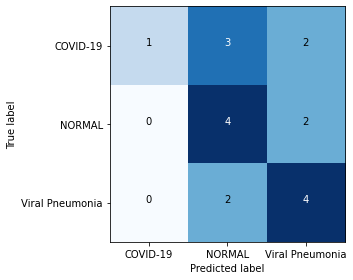

                 precision    recall  f1-score   support

       COVID-19     1.0000    0.1667    0.2857         6
         NORMAL     0.4444    0.6667    0.5333         6
Viral Pneumonia     0.5000    0.6667    0.5714         6

       accuracy                         0.5000        18
      macro avg     0.6481    0.5000    0.4635        18
   weighted avg     0.6481    0.5000    0.4635        18



In [10]:
import matplotlib.pyplot as plt
import sklearn
from itertools import product
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from keras.models import load_model
#from keras.weights import load_weights

model.load_weights('/content/drive/My Drive/Colab Notebooks/model.h5')


def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    #plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0)
    plt.yticks(tick_marks, classes, rotation=0)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range (cm.shape[0]):
      for j in range (cm.shape[1]):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig('/content/drive/My Drive/Colab Notebooks/confusion_matrix.jpg')


img_row, img_height, img_depth = 224,224,3

class_labels = test_ds.class_indices
class_labels = {v: k for k, v in class_labels.items()}
classes = list(class_labels.values())

#Confution Matrix and Classification Report
Y_pred = model.predict_generator(test_ds)
y_pred = np.argmax(Y_pred, axis=1)

target_names = list(class_labels.values())

predicted_classes = np.argmax(Y_pred, axis=1)

# Generate the confusion matrix
cnf_matrix = confusion_matrix(test_ds.classes, y_pred)
#cnf_matrix = confusion_matrix(testdata.class_indices, y_pred)

# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=classes,
                      title='')

plt.show()

print(classification_report(test_ds.classes, y_pred, target_names=target_names,digits=4))